<a href="https://colab.research.google.com/github/YanuarRamadhaniKuswoko/PCVK_Sem5/blob/main/Pertemuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PRAKTIKUM**

**D1. Operasi Citra Sederhana**

In [1]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


/tmp/ipykernel_5787/2421645898.py:17: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


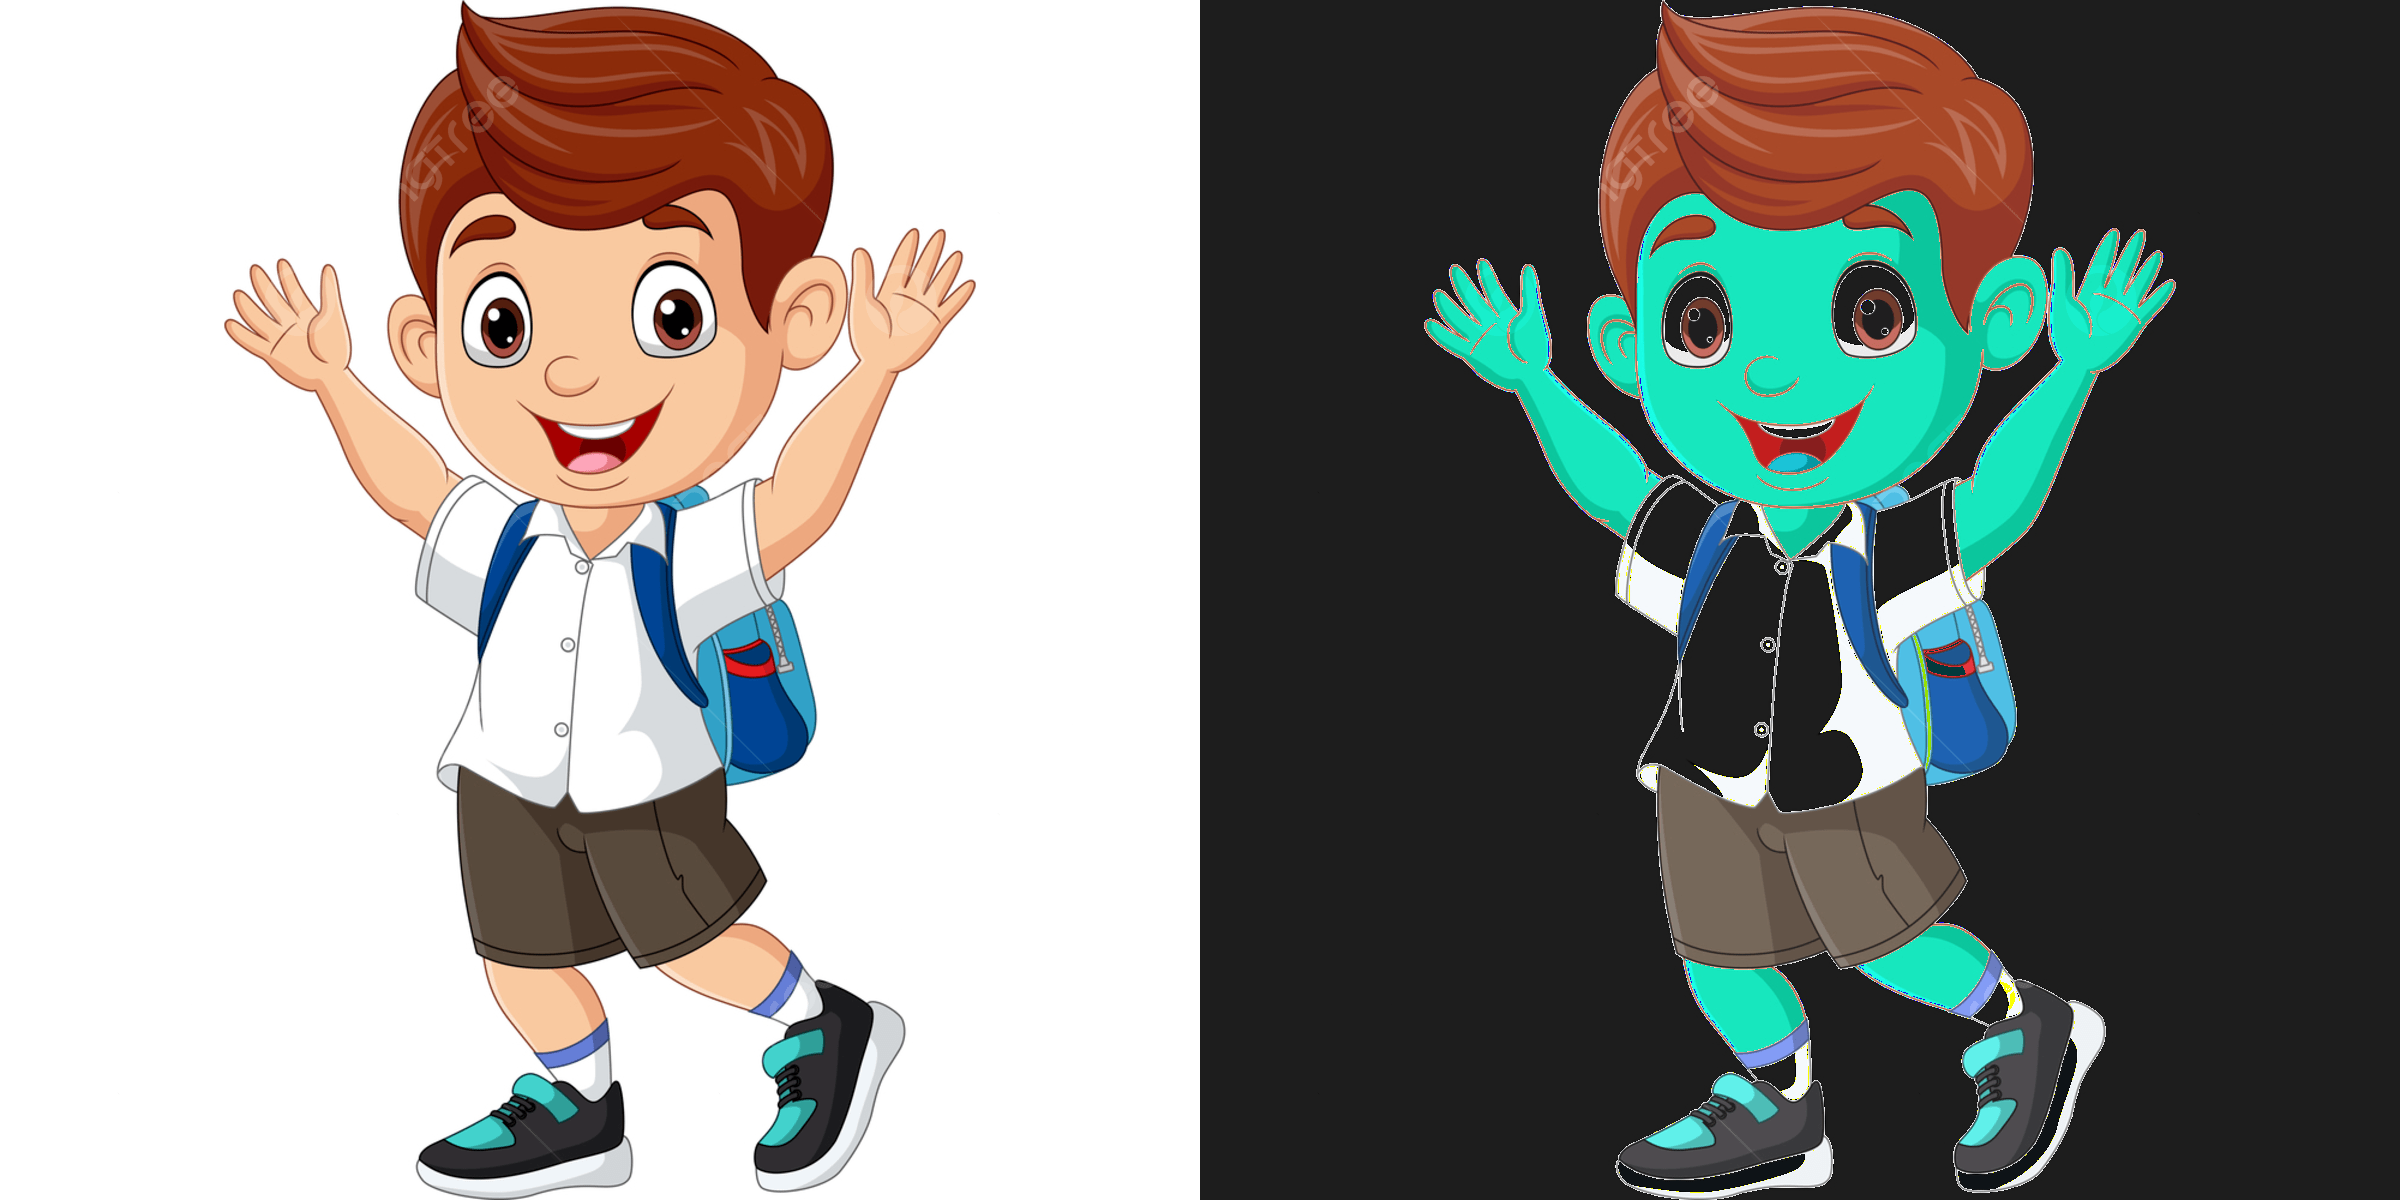

In [2]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/pngtree-cartoon-happy-school-boy-raising-hands-png-image_7853312.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

**TUGAS PRAKTIKUM**

1.Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

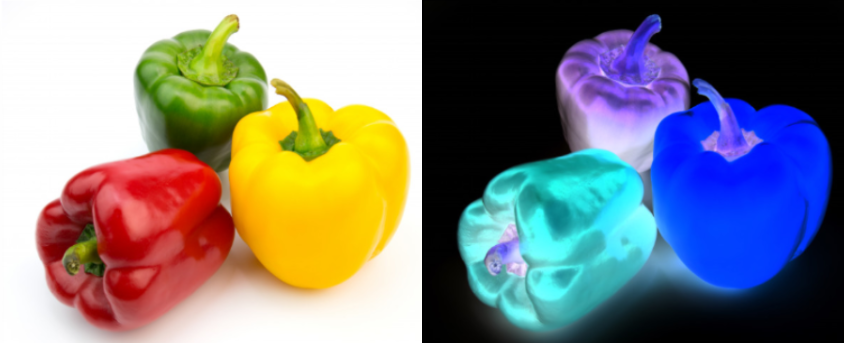

In [3]:
# Modul Inverse Citra (Citra Negatif)
original = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak1-Screenshot 2026-09-10 125435.jpg')
inverse_image = np.zeros(original.shape, original.dtype)

# Akses per piksel menggunakan formula: g(x,y) = 255 - f(x,y)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

# Cara simple tanpa loop (operasi matriks NumPy)
# inverse_image = 255 - original

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

2.Implementasikan transformasi contrast pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga menghasilkan keluaran seperti berikut:

Mengubah kontras dan tingkat kecerahan citra
Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


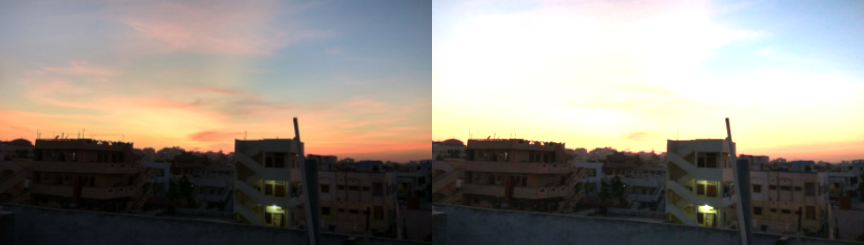

In [13]:
print('Mengubah kontras dan tingkat kecerahan citra')
try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
    contrast = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak2-Screenshot 2026-09-10 130105.jpg')
contrast_img = np.zeros(img.shape, img.dtype)

# Menghitung contrast & brightness
for y in range(img.shape[0]):
    for x in range(img.shape[1]):
        for c in range(img.shape[2]):
            contrast_img[y, x, c] = np.clip(contrast * img[y, x, c] + brightness, 0, 255)

final = cv.hconcat((img, contrast_img))
cv2_imshow(final)

3.Implementasikan transformasi logarithmic brightness pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi log, sehingga menghasilkan keluaran seperti berikut:

Mengubah tingkat kecerahan citra dengan Transformasi Log
Masukkan nilai kecerahan / konstanta: 50


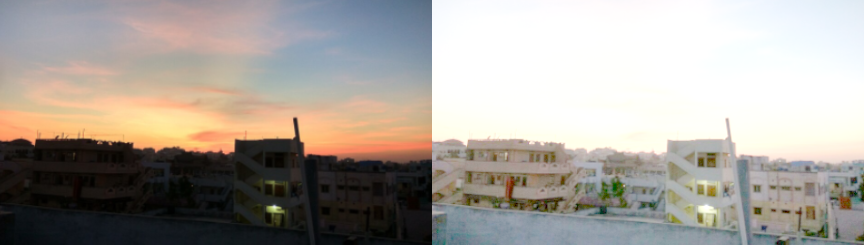

In [16]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
try:
    c_val = float(input('Masukkan nilai kecerahan / konstanta: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak2-Screenshot 2026-09-10 130105.jpg')

# Konversi citra ke float untuk perhitungan logaritma
img_float = img.astype(np.float32)

# Rumus Logarithmic Transformation: s = c * log(1 + r)
# Menggunakan log1p (log(1 + x))
c = 255 / np.log(1 + np.max(img_float)) if c_val == 0 else c_val
log_img = c * np.log1p(img_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

final = cv.hconcat((img, log_img))
cv2_imshow(final)

4.Implementasikan transformasi grayscale menggunakan metode averaging, lightness, dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

a.Averaging

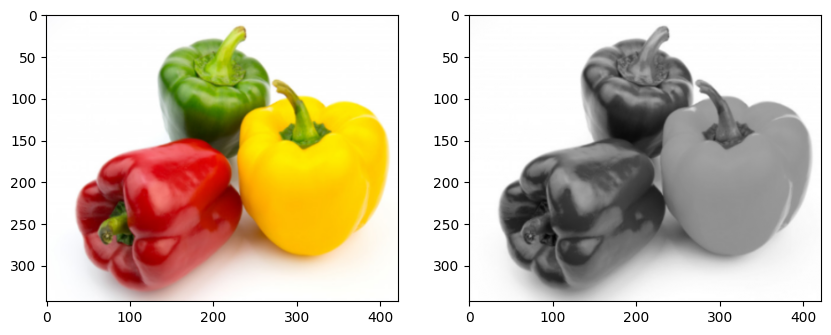

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak1-Screenshot 2026-09-10 125435.jpg')
gray_avg = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

# Rumus Averaging: (R + G + B) / 3
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        gray_avg[y, x] = np.clip((int(r) + int(g) + int(b)) / 3, 0, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.imshow(gray_avg, cmap='gray')
plt.show()

b.Lightness

/tmp/ipykernel_5787/257083645.py:12: RuntimeWarning: overflow encountered in scalar add
  gray_lightness[y, x] = np.clip((max(r, g, b) + min(r, g, b)) / 2, 0, 255)


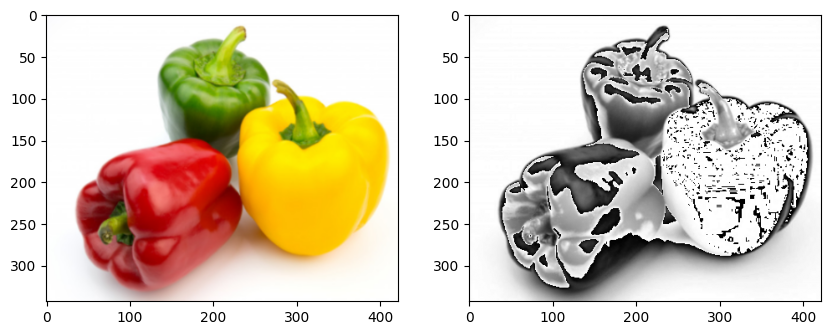

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak1-Screenshot 2026-09-10 125435.jpg')
gray_lightness = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

# Rumus Lightness: (max(R, G, B) + min(R, G, B)) / 2
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        gray_lightness[y, x] = np.clip((max(r, g, b) + min(r, g, b)) / 2, 0, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.imshow(gray_lightness, cmap='gray')
plt.show()

c.Luminance

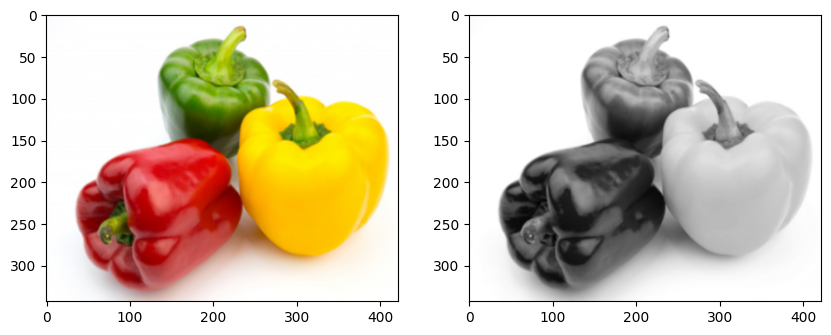

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak1-Screenshot 2026-09-10 125435.jpg')
gray_luminance = np.zeros((original.shape[0], original.shape[1]), dtype=np.uint8)

# Rumus Luminance: 0.21*R + 0.72*G + 0.07*B
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = original[y, x]
        gray_luminance[y, x] = np.clip(0.21 * r + 0.72 * g + 0.07 * b, 0, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.imshow(gray_luminance, cmap='gray')
plt.show()

5.Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal, tampilkan warna merah pada citra masukan dan ubah bagian lain yang tidak berwarna merah menjadi grayscale seperti pada contoh berikut:

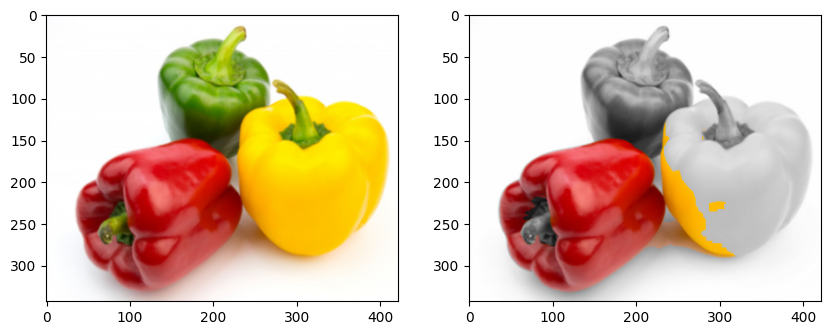

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak1-Screenshot 2026-09-10 125435.jpg')
result = np.zeros(original.shape, original.dtype)

# Menyeleksi MURNI warna merah
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        b, g, r = int(original[y, x][0]), int(original[y, x][1]), int(original[y, x][2])

        # Kondisi ketat agar warna kuning (R tinggi + G tinggi) tidak ikut lolos
        if r > 100 and r > (g * 1.35) and r > (b * 1.35):
            result[y, x] = original[y, x]  # Tetap tampilkan warna asli
        else:
            gray = int(0.21 * r + 0.72 * g + 0.07 * b)
            result[y, x] = [gray, gray, gray]  # Ubah ke grayscale

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.show()

**6.Gamma Correction**

Masukkan nilai Gamma: 0.5


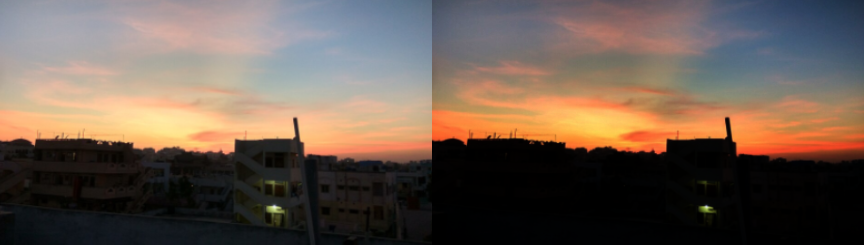

In [17]:
#Gamma Correction
gamma = float(input('Masukkan nilai Gamma: '))
img = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak2-Screenshot 2026-09-10 130105.jpg')

gamma_corrected = np.array(255 * (img / 255.0) ** (1.0 / gamma), dtype='uint8')

cv2_imshow(cv.hconcat((img, gamma_corrected)))

**7.Simulasi Image Depth**

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8



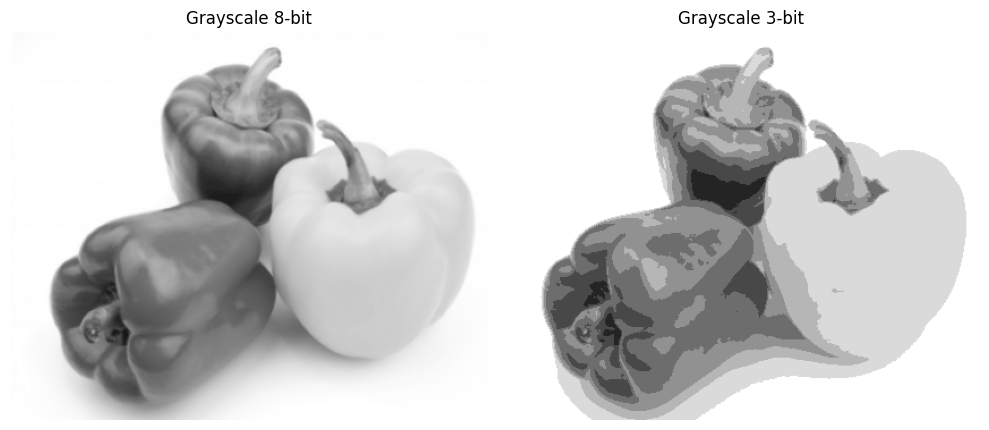

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Input bit depth dari pengguna
bit_depth = int(input("Masukkan bit depth tujuan (1-8): "))

# 2. Hitung jumlah level dan pembagi kuantisasi
num_levels = 2 ** bit_depth
level = 255 / (num_levels - 1)

# 3. Cetak ringkasan informasi sesuai tampilan gambar
print(f"Bit depth awal  : 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level    : {num_levels}\n")

# 4. Baca gambar asli dalam skala abu-abu
original = cv.imread('/content/drive/MyDrive/PCVK/W3-Prak1-Screenshot 2026-09-10 125435.jpg', cv.IMREAD_GRAYSCALE)

if original is None:
    raise FileNotFoundError("Gambar tidak ditemukan, periksa kembali path gambar kamu!")

# 5. Kuantisasi warna (Vektorisasi NumPy agar jauh lebih cepat dibanding per-pixel loop)
depth_image = np.round(original / level) * level
depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)

# 6. Menampilkan hasil gambar
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.title('Grayscale 8-bit')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap='gray', vmin=0, vmax=255)
plt.title(f'Grayscale {bit_depth}-bit')
plt.axis('off')

plt.tight_layout()
plt.show()

**8.Average Denoising**

N=10, PSNR=29.73 dB
N=20, PSNR=31.30 dB
N=40, PSNR=32.37 dB
N=80, PSNR=33.03 dB
N=100, PSNR=33.17 dB


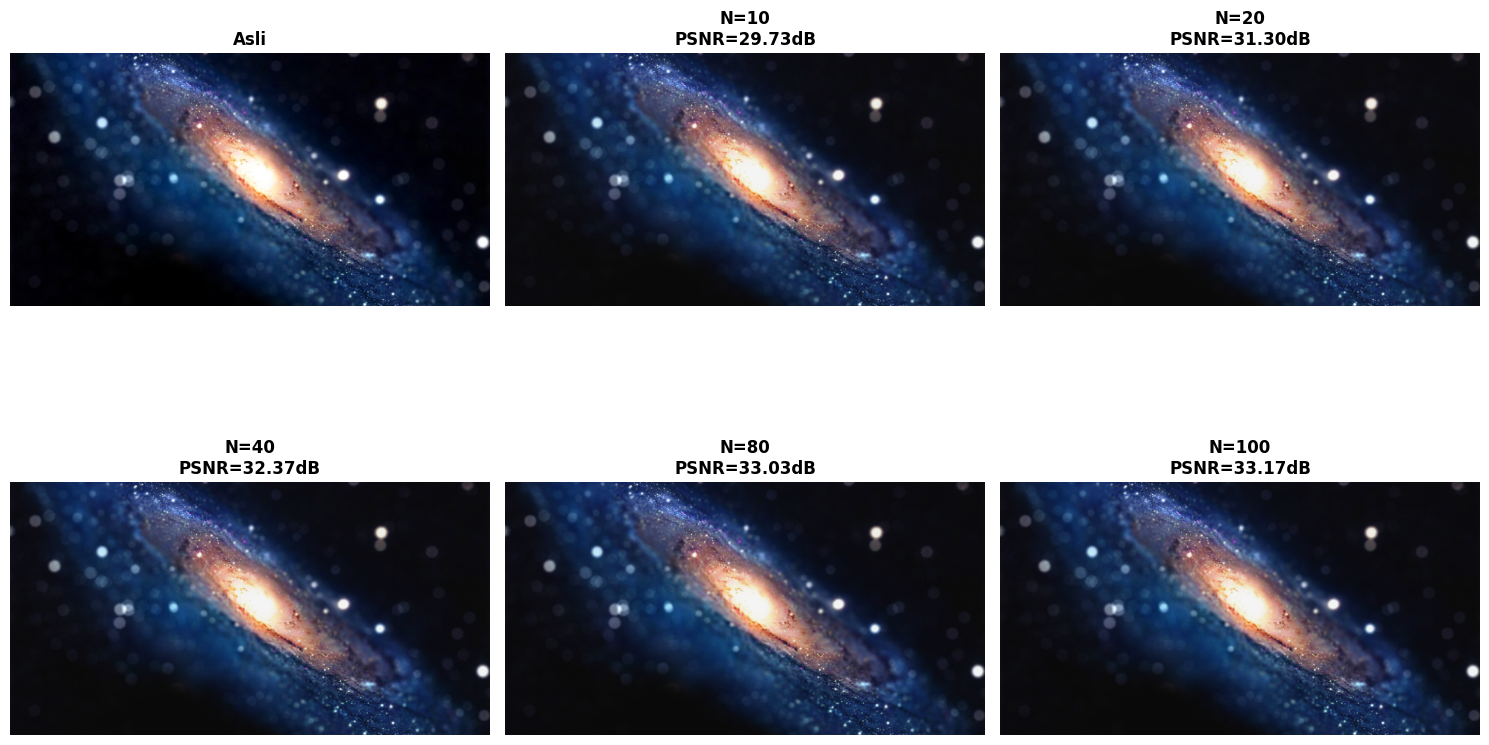

In [18]:
import cv2
# Load gambar
img = cv2.imread('/content/drive/MyDrive/PCVK/250549.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Fungsi PSNR
def calculate_psnr(original, noisy):
    mse = np.mean((original.astype(float) - noisy.astype(float)) ** 2)
    return 20 * np.log10(255.0 / np.sqrt(mse)) if mse != 0 else float('inf')

# Parameter
sigma = 25
num_images_list = [10, 20, 40, 80, 100]
results = []
filtered_images = {}

# Proses filtering
for num_images in num_images_list:
    filtered = np.zeros_like(img, dtype=float)
    for _ in range(num_images):
        noise = np.random.normal(0, sigma, img.shape)
        noisy = np.clip(img.astype(float) + noise, 0, 255)
        filtered += noisy / num_images

    filtered = np.clip(filtered, 0, 255).astype(np.uint8)
    filtered_images[num_images] = filtered
    psnr = calculate_psnr(img, filtered)
    results.append({'num': num_images, 'psnr': psnr})
    print(f"N={num_images}, PSNR={psnr:.2f} dB")

# Tampilkan gambar
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(img_rgb)
axes[0].set_title('Asli', fontweight='bold')
axes[0].axis('off')

for i, num_images in enumerate(num_images_list, 1):
    axes[i].imshow(cv2.cvtColor(filtered_images[num_images], cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'N={num_images}\nPSNR={results[i-1]["psnr"]:.2f}dB', fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

-Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?

jawab:ya. Semakin banyak citra yang dirata-rata, semakin tinggi nilai PSNR. Ini terjadi karena averaging mengurangi noise secara statistik Noise random saling membatalkan ketika di-average struktur gambar asli terpreservasi lebih baik

-Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan? Apa Kesimpulan yang Anda peroleh dari percobaan ini?

jawab:Peningkatan paling signifikan terjadi dari 10→20→40. Setelah 80 citra, peningkatan mulai menurun (diminishing returns).Kesimpulan: Averaging adalah teknik filtering efektif untuk mengurangi Gaussian Noise, namun efektivitasnya berkurang seiring bertambahnya jumlah citra. Trade-off antara kualitas (PSNR) dan waktu komputasi perlu dipertimbangkan.


**9.Buat image masking**

--- Masking yang digunakan (Untuk Kolom Image Input) ---


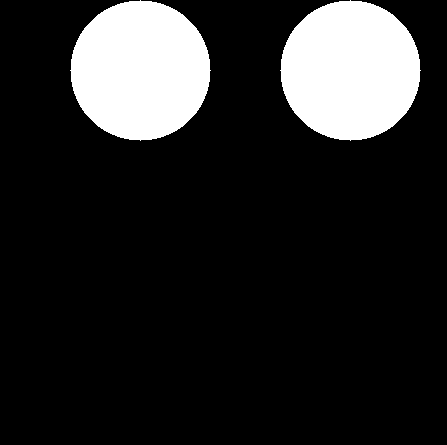


------------------------------------------------------

1. NOT (Komplemen Citra Asli)


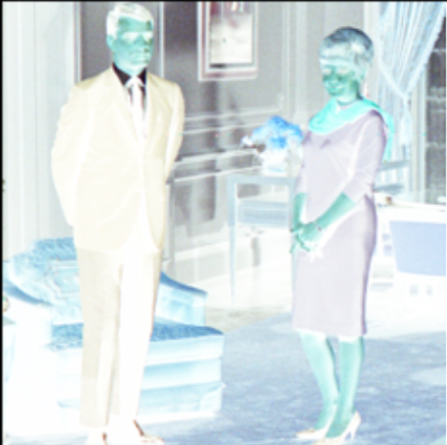


2. OR


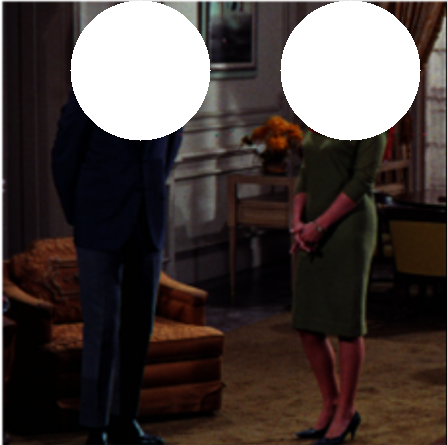


3. AND (Image Masking)


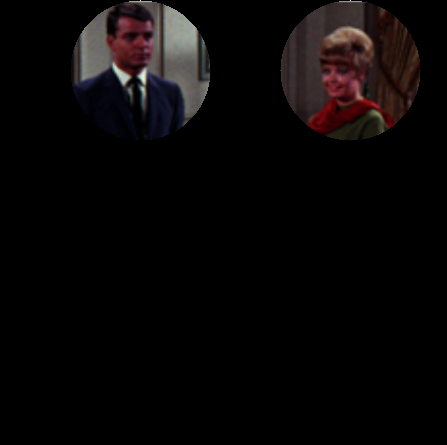


4. NAND


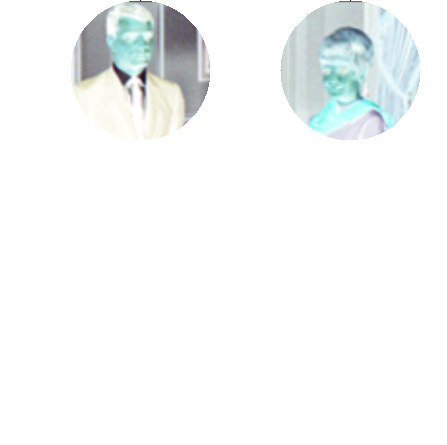


5. XOR


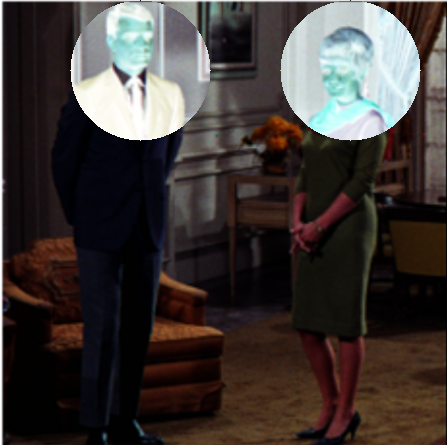

In [24]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

img_couple = cv.imread('/content/drive/MyDrive/PCVK/W3-Tugas-Screenshot 2026-09-10 203114.jpg')

# Membuat kanvas hitam dengan ukuran yang sama dengan gambar asli
mask = np.zeros_like(img_couple)

# Adjust posisi lingkaran untuk tepat di wajah pria (kiri) dan wanita (kanan)
cv.circle(mask, (140, 70), 70, (255, 255, 255), -1)   # Wajah pria (kiri)
cv.circle(mask, (350, 70), 70, (255, 255, 255), -1)  # Wajah wanita (kanan)

print("--- Masking yang digunakan (Untuk Kolom Image Input) ---")
cv2_imshow(mask)
print("\n------------------------------------------------------\n")

print("1. NOT (Komplemen Citra Asli)")
cv2_imshow(cv.bitwise_not(img_couple))

print("\n2. OR")
cv2_imshow(cv.bitwise_or(img_couple, mask))

print("\n3. AND (Image Masking)")
cv2_imshow(cv.bitwise_and(img_couple, mask))

print("\n4. NAND")
cv2_imshow(cv.bitwise_not(cv.bitwise_and(img_couple, mask)))

print("\n5. XOR")
cv2_imshow(cv.bitwise_xor(img_couple, mask))


**10.Foto Malam Hari**

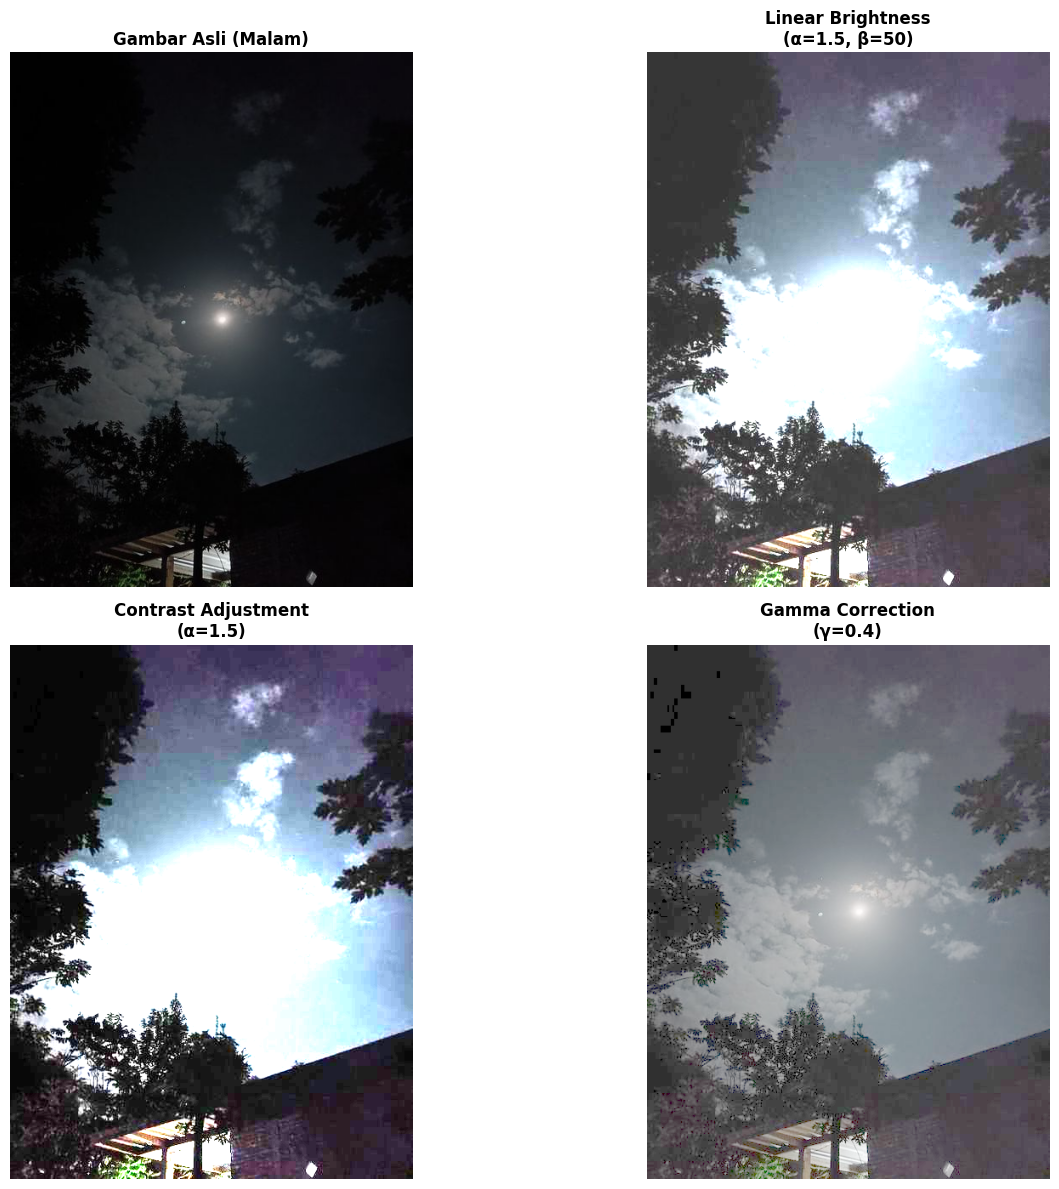

In [25]:
#foto malam hari
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

# Load gambar
img = cv.imread('/content/drive/MyDrive/PCVK/W3-TUGAS016c667e630f67006e1f41b2cb551b5c.jpg')

# Konversi ke RGB untuk matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 1. LINEAR BRIGHTNESS
def linear_brightness(img, alpha=1.5, beta=50):
    result = cv.convertScaleAbs(img, alpha=alpha, beta=beta)
    return result

# 2. CONTRAST
def contrast_adjustment(img, alpha=1.5):
    result = cv.convertScaleAbs(img, alpha=alpha, beta=0)
    return result

# 3. GAMMA CORRECTION
def gamma_correction(img, gamma=0.5):
    # Normalisasi 0-1
    img_normalized = img.astype(float) / 255.0
    # Aplikasikan gamma
    result = np.power(img_normalized, gamma)
    # Kembali ke 0-255
    result = (result * 255).astype(np.uint8)
    return result

# Terapkan ketiga metode
brightness_result = linear_brightness(img, alpha=4.5, beta=50)
contrast_result = contrast_adjustment(img, alpha=7.5)
gamma_result = gamma_correction(img, gamma=0.3)

# Tampilkan hasil
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Gambar Asli (Malam)', fontweight='bold', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(cv.cvtColor(brightness_result, cv.COLOR_BGR2RGB))
axes[0, 1].set_title('Linear Brightness\n(α=1.5, β=50)', fontweight='bold', fontsize=12)
axes[0, 1].axis('off')

axes[1, 0].imshow(cv.cvtColor(contrast_result, cv.COLOR_BGR2RGB))
axes[1, 0].set_title('Contrast Adjustment\n(α=1.5)', fontweight='bold', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(cv.cvtColor(gamma_result, cv.COLOR_BGR2RGB))
axes[1, 1].set_title('Gamma Correction\n(γ=0.4)', fontweight='bold', fontsize=12)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


**Linear Brightness** menawarkan cara paling sederhana dan cepat untuk mencerahkan foto dengan menambahkan nilai piksel secara langsung tanpa perhitungan rumit. Metode ini cocok untuk foto yang hanya sedikit gelap, namun berisiko tinggi menyebabkan clipping atau over-exposure, di mana area yang sudah terang berubah menjadi putih polos sehingga detailnya hilang. Selain itu, peningkatan kecerahan yang merata di seluruh area membuat noise pada bagian gelap makin terlihat dan hasilnya tampak kurang alami.

**Contrast Adjustment** berfungsi mempertegas perbedaan antara area gelap dan terang sehingga struktur serta detail tepi objek pada foto yang pudar tampak lebih tajam. Kendati efektif untuk foto bersaturasi rendah, metode ini dapat memperkuat noise secara signifikan dan menyebabkan hilangnya detail di area shadow maupun highlight. Metode ini kurang efektif untuk mencerahkan foto yang sangat gelap dan dapat memicu halo effect di sekitar garis batas objek.

**Gamma Correction** merupakan opsi terbaik untuk foto malam atau area gelap karena menggunakan pendekatan non-linear yang menyesuaikan kecerahan secara proporsional. Metode ini mampu mempertahankan detail pada area shadow dan highlight dengan hasil yang lebih alami menyerupai cara pandang mata manusia. Meski tetap memerlukan penyesuaian nilai gamma secara eksperimental dan berisiko clipping pada nilai ekstrem, cara ini lebih cerdas dalam mengendalikan noise, terutama jika dipadukan dengan denoising filter.

**11.Perbaiki kualitas pada citra tersebut dengan metode operasi dasar citra apapun. Diperbolehkan menggunakan lebih dari 1 metode. Kemudian jelaskan**

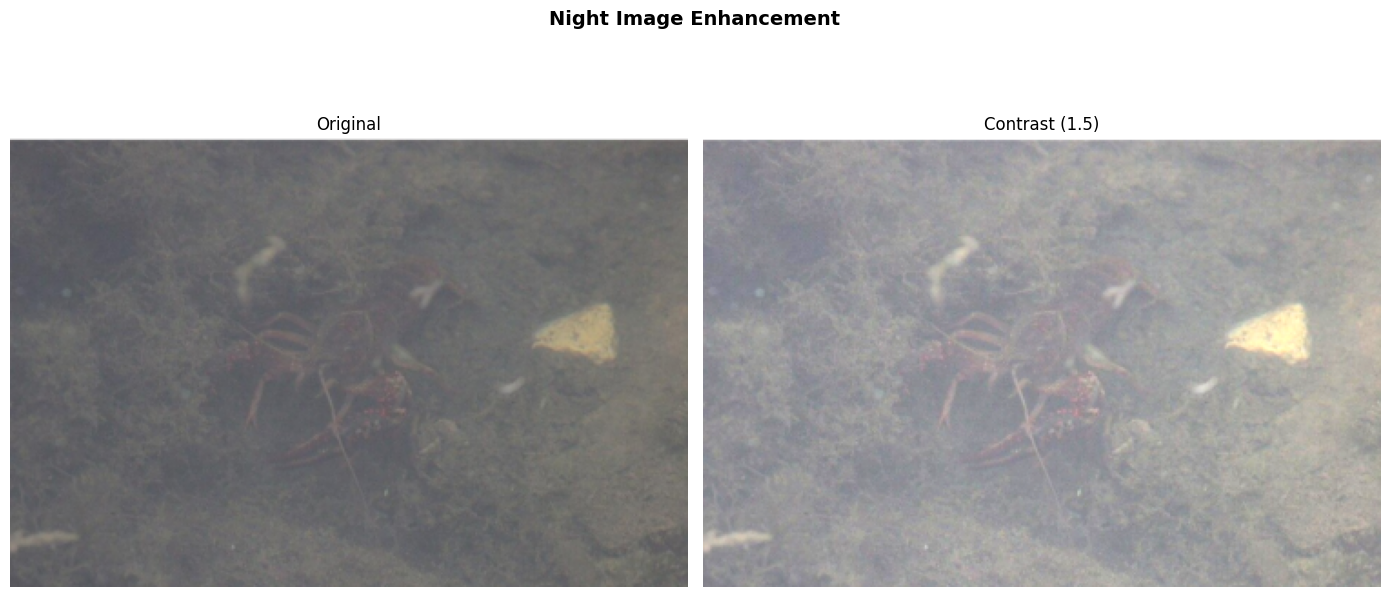

In [27]:
import cv2
import matplotlib.pyplot as plt

# 1. Definisi fungsi contrast_adjustment yang mendukung alpha dan beta
def contrast_adjustment(img, alpha=1.0, beta=0):
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

# 2. Path dan parameter
IMAGE_PATH = "/content/drive/MyDrive/PCVK/W3-Tugas11Screenshot 2026-09-10 204547.png"
ALPHA_CONTRAST = 1.5
BETA_BRIGHTNESS = 0

# 3. Baca gambar
original = cv2.imread(IMAGE_PATH)

if original is None:
    print(f"Error: Gambar tidak ditemukan di path '{IMAGE_PATH}'. Pastikan path benar dan Drive sudah di-mount.")
else:
    # 4. Konversi warna dan proses kontras
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Sekarang fungsi ini aman menerima 3 argumen (image, alpha, beta)
    adjusted_img = contrast_adjustment(original, ALPHA_CONTRAST, BETA_BRIGHTNESS)
    contrast_image = cv2.cvtColor(adjusted_img, cv2.COLOR_BGR2RGB)

    # 5. Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle('Night Image Enhancement', fontsize=14, fontweight='bold')

    axes[0].imshow(original_rgb)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(contrast_image)
    axes[1].set_title(f'Contrast ({ALPHA_CONTRAST})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

1.Metode yang Dipilih
Penyesuaian Kontras (Contrast Adjustment), bertujuan memperjelas detail dan struktur gambar dengan mempertegas perbedaan area terang dan gelap.

2.Alasan Pemilihan
Metode ini efektif mengatasi foto yang pudar atau datar (bland), sehingga objek seperti crayfish dan tekstur di sekitarnya tampak lebih tajam dan menonjol.

3.Penentuan Parameter Terbaik
Parameter ALPHA_CONTRAST diset pada angka 1.5. Nilai pengali ini dipilih melalui eksperimen visual untuk memberikan peningkatan kontras yang optimal tanpa memicu over-exposed maupun under-exposed.

4.Hasil Before-After
Perbandingan menunjukkan gambar Contrast (1.5) memiliki detail dan tekstur yang jauh lebih jelas serta tidak lagi tampak buram dibandingkan gambar Original.